---
title: "Salary Linear Regression Model"
format:
  html:
    code-fold: false
    code-overflow: wrap
    code-tools: false
    echo: false
    warning: false
    message: false
---

In [49]:
# Import Necessary Libraries
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import os 

In [50]:
# Load in Dataset
jobdata = pd.read_csv("data/jobs_in_data_2024.csv")

# Introduction

The aim of this section is to run a linear regression model for factors that influence Salaries within Data-related careers. The data was sourced via Kaggle, which takes data from ai-jobs.net, based on internal data survey submissions regarding jobs and salaries. The dictionary can be found through the links. 

In [ ]:
# Display First 10 Rows of Dataset
# jobdata.head(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,work_setting,company_location,company_size,job_category
0,2024,Entry-level,Freelance,Applied Data Scientist,30000,USD,30000,United Kingdom,Remote,United Kingdom,M,Data Science and Research
1,2024,Executive,Full-time,Business Intelligence,230000,USD,230000,United States,In-person,United States,M,BI and Visualization
2,2024,Executive,Full-time,Business Intelligence,176900,USD,176900,United States,In-person,United States,M,BI and Visualization
3,2024,Senior,Full-time,Data Architect,171210,USD,171210,Canada,In-person,Canada,M,Data Architecture and Modeling
4,2024,Senior,Full-time,Data Architect,92190,USD,92190,Canada,In-person,Canada,M,Data Architecture and Modeling


In [ ]:
# Check for Missing Values
# jobdata.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
work_setting          0
company_location      0
company_size          0
job_category          0
dtype: int64

Below gives context to the salary range and values that are present in the dataset. We see a range from $15,000 to $450,000. The median value is $142,000. 

In [133]:

jobdata['salary_in_usd'].describe()

count     14199.00000
mean     149472.04944
std       64379.26016
min       15000.00000
25%      104000.00000
50%      142000.00000
75%      185900.00000
max      450000.00000
Name: salary_in_usd, dtype: float64

In [54]:
fig = px.histogram(
    jobdata,
    x='salary_in_usd',
    nbins=50, 
    title='Distribution of Salary in USD')

fig.update_layout(
    xaxis_title='Salary in USD',
    yaxis_title='Count',
    margin=dict(l=40, r=40, t=50, b=40))

import os
import plotly.express as px
os.makedirs("plots", exist_ok=True)
fig.write_html("plots/salary_distribution_histogram.html", include_plotlyjs="cdn")
fig.show()

This plot displays the distibution of the values in the dataset. Between 15,000 (minimum value) to $300,000, we can see that there is a normal distribution when their is a unimodal peak between $140,000 and $150,000, which represents the median value. From $300,000 onwards there is a right-hand skew, with values ranging out to $450,000. 

In [55]:
avg_salary_df = jobdata.groupby('experience_level', as_index=False)['salary_in_usd'].mean().sort_values(by='salary_in_usd', ascending=True)

fig_bar = px.bar(
    avg_salary_df,
    x='experience_level',
    y='salary_in_usd',
    title='Average Salary by Experience Level',
)

fig_bar.update_layout(
    xaxis_title='Experience Level',
    yaxis_title='Average Salary in USD'
)

import os
import plotly.express as px
os.makedirs("plots", exist_ok=True)
fig_bar.write_html("plots/average_salary_by_experience.html", include_plotlyjs="cdn")
fig_bar.show()

Ths plot shows the breakdown of average salary by experience level. The increase between each level of experience ranges between $30,000 to $40,000. 

In [56]:
fig_box = px.box(
    jobdata,
    x='job_category',
    y='salary_in_usd',
    title='Salary Distribution by Job Category'
)

fig_box.update_layout(
    xaxis_title='Job Category',
    yaxis_title='Salary in USD',
    xaxis={'tickangle': 45},
    margin=dict(l=40, r=40, t=50, b=40)
)

import os
import plotly.express as px
os.makedirs("plots", exist_ok=True)
fig_box.write_html("plots/salary_by_job_category_boxplot.html", include_plotlyjs="cdn")
fig_box.show()

This plot provides significant insight into the salary distribution for each job category. Whilst we can see the distrbituions of the salaries on a micro-level per category, we are able to gain insight into the lowest and highest performing categories as well as those with the largest range. Machine Learning and AI presents itself as the highest performing job category with an average salary of $180,000. It is important to note however that it also has the largest range from only $15,000 to $448,000. This may suggest that this is a high growth job category with plenty of opportunity for salary growth. 

Most other categories fall within a median salary range of $120,000-$150,000. These all present solid Q1 and Q3 salary values. Included in this category are Data Science and Research, Data Architecture and Modeling, Data Engineering, and Leadership and Modeling. 

The two most notable lower performing categories based on salary are the Data Analysis and Data Quality and Operations, with median salaries of $100,000 and $82,000 respectively. It is important to note the differences in their distribution becasue the Data Analysis Category ranges up to $430,000, whereas the Data Quality and Operations caps out at $289,000. 

Interestingly, Cloud and Database has the smallest total range, with the minimum value falling at $82,000 which is the highest minimum value, but the salary caps out at $190,000. The median value for the Cloud and Database Category is $146,000. These insights suggest that at an entry level this may be a high performing category, but growth opportunities are limited. BI and Visualization and Data Management and Strategy also present themselves as low growth job categories, despite still have lower Q1 and median values.

## Linear Regression Model

In [96]:
# print all of them in a list the different company locations and their counts
# jobdata['company_location'].unique()

In [134]:
def country_to_continent(country_name):
    """
    Maps a country name to its corresponding continent code.
    'NA': North America, 'SA': South America, 'EU': Europe, 
    'AS': Asia, 'AF': Africa, 'OC': Oceania/Australia
    """
    continents = {
        'NA': [
            'United States', 'Canada', 'Mexico', 'Puerto Rico', 'Bahamas', 
            'Honduras'
        ],
        'SA': [
            'Brazil', 'Argentina', 'Colombia', 'Ecuador'
        ],
        'EU': [
            'United Kingdom', 'Lithuania', 'Poland', 'France', 'Germany', 
            'Netherlands', 'Austria', 'Spain', 'Finland', 'Türkiye', 
            'Switzerland', 'Portugal', 'Bosnia and Herzegovina', 'Latvia', 
            'Italy', 'Ireland', 'Estonia', 'Malta', 'Hungary', 'Romania', 
            'Luxembourg', 'Gibraltar', 'Slovenia', 'Greece', 'Czechia', 
            'Denmark', 'Sweden', 'Andorra', 'Croatia', 'Belgium', 'Moldova, Republic of'
        ],
        'AS': [
            'Saudi Arabia', 'United Arab Emirates', 'Oman', 'Lebanon', 
            'Viet Nam', 'Qatar', 'Russian Federation', 
            'Korea, Republic of', 'Japan', 'Singapore', 'Thailand', 
            'Indonesia', 'Malaysia', 'China', 'Iraq', 'Iran, Islamic Republic of', 
            'Pakistan', 'India', 'Israel', 'Armenia'
        ],
        'AF': [
            'Egypt', 'South Africa', 'Nigeria', 'Kenya', 'Ghana', 
            'Central African Republic', 'Algeria', 'Mauritius'
        ],
        'OC': [
            'Australia', 'New Zealand', 'Philippines', 
            'American Samoa'
        ],
    }
    for continent, countries in continents.items():
        if country_name in countries:
            return continent
    
    return 'Other'

country_array = [
    'United Kingdom', 'United States', 'Canada', 'Lithuania', 'Poland', 
    'France', 'Germany', 'Saudi Arabia', 'Australia', 'United Arab Emirates', 
    'Ukraine', 'Netherlands', 'Egypt', 'Austria', 'Spain', 'Philippines', 
    'Finland', 'Türkiye', 'Switzerland', 'Oman', 'New Zealand', 'Mexico', 
    'Portugal', 'Bosnia and Herzegovina', 'Brazil', 'Argentina', 'Latvia', 
    'South Africa', 'Italy', 'American Samoa', 'Ireland', 'Estonia', 'India', 
    'Malta', 'Hungary', 'Lebanon', 'Romania', 'Viet Nam', 'Nigeria', 
    'Luxembourg', 'Gibraltar', 'Colombia', 'Slovenia', 'Greece', 'Mauritius', 
    'Russian Federation', 'Korea, Republic of', 'Czechia', 'Qatar', 'Kenya', 
    'Denmark', 'Ghana', 'Sweden', 'Andorra', 'Ecuador', 'Israel', 'Japan', 
    'Central African Republic', 'Singapore', 'Croatia', 'Armenia', 'Pakistan', 
    'Iran, Islamic Republic of', 'Bahamas', 'Puerto Rico', 'Thailand', 
    'Belgium', 'Indonesia', 'Malaysia', 'Honduras', 'Algeria', 'Iraq', 
    'China', 'Moldova, Republic of'
]

In [115]:
# take continents and add it as a column to the dataframe
jobdata['continent'] = jobdata['company_location'].apply(country_to_continent)

In [114]:
# jobdata['continent'].value_counts()

In [116]:
# drop rows where continent isnt EU or NA
jobdata2 = jobdata[jobdata['continent'].isin(['EU', 'NA'])]

In [117]:
# Select Relevant Columns for Analysis
jobdata2 = jobdata2[['salary_in_usd', 'experience_level', 'job_category', 'work_setting', 'company_size','continent']]

In [119]:
# jobdata2.shape

In [120]:
# Dummify Categorical Variables
jobdata_regression = pd.get_dummies(jobdata2, drop_first=True, columns = ['experience_level', 'job_category', 'work_setting', 'company_size', 'continent'])

In [ ]:
# Display First 5 Rows of Dummified Dataset
# jobdata_regression.head()

,salary_in_usd,experience_level_Executive,experience_level_Mid-level,experience_level_Senior,job_category_Cloud and Database,job_category_Data Analysis,job_category_Data Architecture and Modeling,job_category_Data Engineering,job_category_Data Management and Strategy,job_category_Data Quality and Operations,job_category_Data Science and Research,job_category_Leadership and Management,job_category_Machine Learning and AI,work_setting_In-person,work_setting_Remote,company_size_M,company_size_S,continent_NA
0,30000,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False
1,230000,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True
2,176900,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True
3,171210,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,True
4,92190,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,True


In [121]:
# jobdata_regression.columns

In [68]:
# Prepare Data for Linear Regression
X = jobdata_regression[['experience_level_Executive',
       'experience_level_Mid-level', 'experience_level_Senior',
       'job_category_Cloud and Database',
       'job_category_Data Analysis',
       'job_category_Data Architecture and Modeling',
       'job_category_Data Engineering',
       'job_category_Data Management and Strategy',
       'job_category_Data Quality and Operations',
       'job_category_Data Science and Research',
       'job_category_Leadership and Management',
       'job_category_Machine Learning and AI', 'work_setting_In-person',
       'work_setting_Remote', 'company_size_M', 'company_size_S',
       'continent_NA']]
y = jobdata_regression['salary_in_usd']


In [122]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
# Train Linear Regression Model
from sklearn.linear_model import Ridge
    
# regressor = LinearRegression()
# regressor.fit(X_train,y_train)

In [127]:
# Get Intercept
# regressor.intercept_

In [128]:
# Get Coefficients with Proper Formatting
jobdata_coef = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
jobdata_coef['Coefficient'] = jobdata_coef['Coefficient'].map(lambda x: f"-${abs(x):,.2f}" if x < 0 else f"${x:,.2f}")

In [129]:
# Display Coefficients DataFrame
# enhance this to look better

jobdata_coef

,Coefficient
experience_level_Executive,"$79,849.33"
experience_level_Mid-level,"$17,176.51"
experience_level_Senior,"$45,380.00"
job_category_Cloud and Database,"$6,775.09"
job_category_Data Analysis,"-$10,025.21"
job_category_Data Architecture and Modeling,"$23,536.68"
job_category_Data Engineering,"$20,421.10"
job_category_Data Management and Strategy,"-$15,474.06"
job_category_Data Quality and Operations,"-$25,464.13"
job_category_Data Science and Research,"$36,923.72"


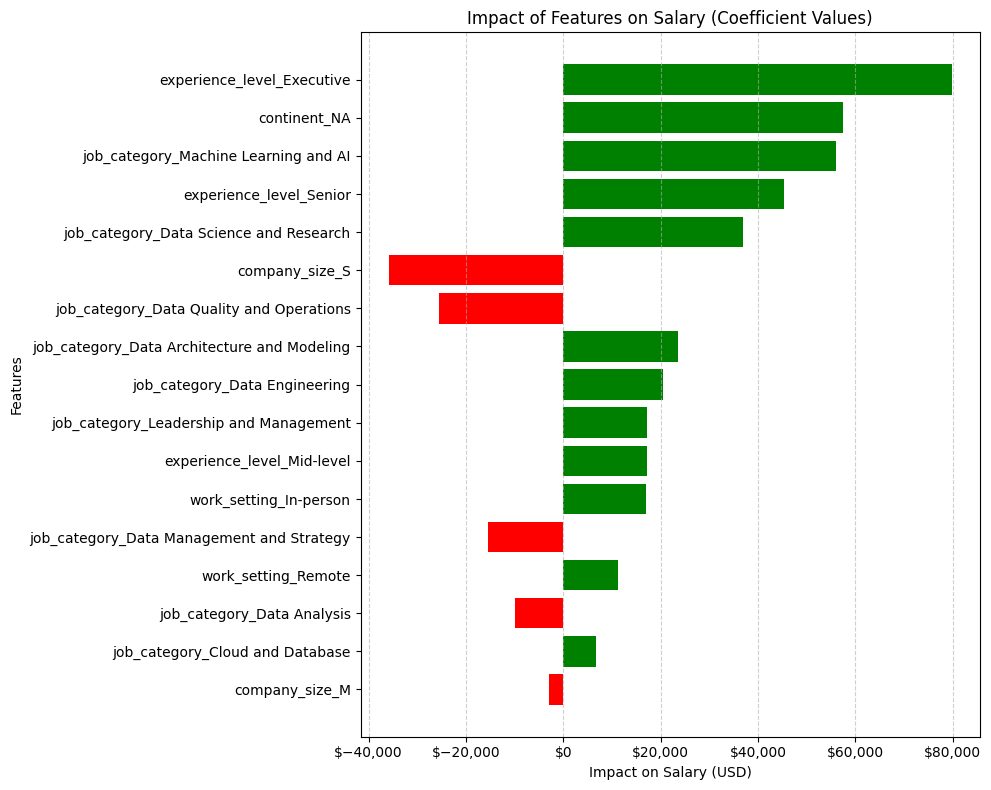

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

jobdata_coef['Coefficient_Cleaned'] = (
    jobdata_coef['Coefficient']
    .astype(str)
    .str.replace('$', '', regex=False) # Remove dollar signs
    .str.replace(',', '', regex=False) # Remove commas
)

jobdata_coef['Coefficient_Cleaned'] = pd.to_numeric(jobdata_coef['Coefficient_Cleaned'], errors='coerce')

jobdata_coef['Absolute_Value'] = jobdata_coef['Coefficient_Cleaned'].abs()
jobdata_coef_sorted = jobdata_coef.sort_values(by='Absolute_Value', ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(
    jobdata_coef_sorted.index, 
    jobdata_coef_sorted['Coefficient_Cleaned'], 
    color=['g' if x > 0 else 'r' for x in jobdata_coef_sorted['Coefficient_Cleaned']]
)

plt.title('Impact of Features on Salary (Coefficient Values)')
plt.xlabel('Impact on Salary (USD)')
plt.ylabel('Features')
formatter = mtick.StrMethodFormatter('${x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

INTERPRETATIONS HERE: 

## Model Evaluation

In [131]:
# Make Predictions on Test Set
y_pred = regressor.predict(X_test)

In [132]:
# Evaluate Model Performance with RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

RMSE: 53478.08996496681


In [104]:
# Calculate RMSE
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

RMSE: 53478.08996496681


In [103]:
# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

R-squared: 0.30224782961474117


In [88]:
# Print Coefficients and Intercept
print(f"Intercept: {regressor.intercept_}")

Intercept: 23927.65786215823


INTERPRETATIONS HERE: 